Problem
Build a Linear Regression system that predicts salary based on experience, education, skills, and
location.
Requirements
Participants must:
1. Find dataset.
2. Perform feature engineering.
3. Handle categorical features.
4. Detect multicollinearity.
5. Train models.
6. Evaluate using:
• MAE
• MSE
• RMSE
• R²
Final Deliverables
• Jupyter Notebook
• visualizations
• detailed explanation

In [2]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from statsmodels.stats.outliers_influence import variance_inflation_factor

In [3]:
df = pd.read_csv("salary_prediction_data.csv")

df.head()

,Education,Experience,Location,Job_Title,Age,Gender,Salary
0,High School,8,Urban,Manager,63,Male,84620.053665
1,PhD,11,Suburban,Director,59,Male,142591.255894
2,Bachelor,28,Suburban,Manager,61,Female,97800.255404
3,High School,29,Rural,Director,45,Male,96834.671282
4,PhD,25,Urban,Analyst,26,Female,132157.786175


In [4]:
df.shape


(1000, 7)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Education   1000 non-null   str    
 1   Experience  1000 non-null   int64  
 2   Location    1000 non-null   str    
 3   Job_Title   1000 non-null   str    
 4   Age         1000 non-null   int64  
 5   Gender      1000 non-null   str    
 6   Salary      1000 non-null   float64
dtypes: float64(1), int64(2), str(4)
memory usage: 54.8 KB


In [6]:
df.isnull().sum()

Education     0
Experience    0
Location      0
Job_Title     0
Age           0
Gender        0
Salary        0
dtype: int64

In [7]:
df.describe()

,Experience,Age,Salary
count,1000.000000,1000.000000,1000.000000
mean,14.771000,42.377000,105558.404239
std,8.341111,13.609412,28256.972075
min,1.000000,20.000000,33510.510669
25%,7.000000,30.000000,85032.141517
50%,15.000000,43.000000,104314.518315
75%,22.000000,55.000000,126804.047524
max,29.000000,64.000000,193016.602150


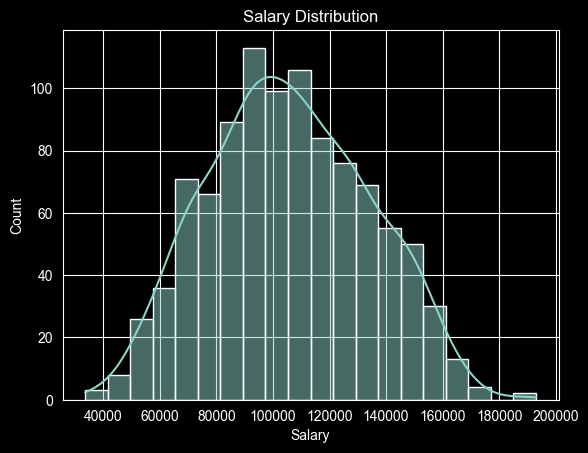

In [24]:
sns.histplot(df["Salary"], kde=True)
plt.title("Salary Distribution")
plt.show()

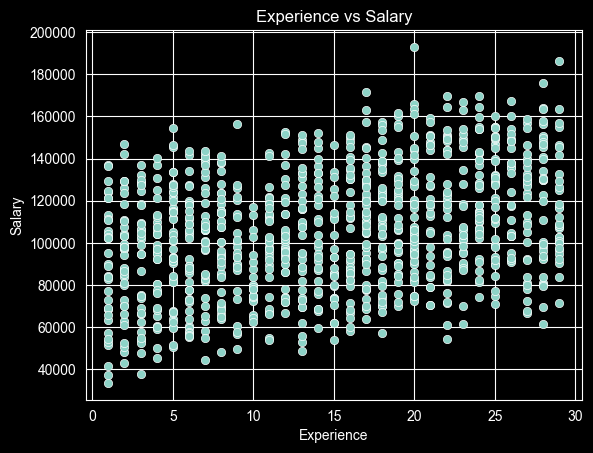

In [25]:
sns.scatterplot(x="Experience", y="Salary", data=df)
plt.title("Experience vs Salary")
plt.show()

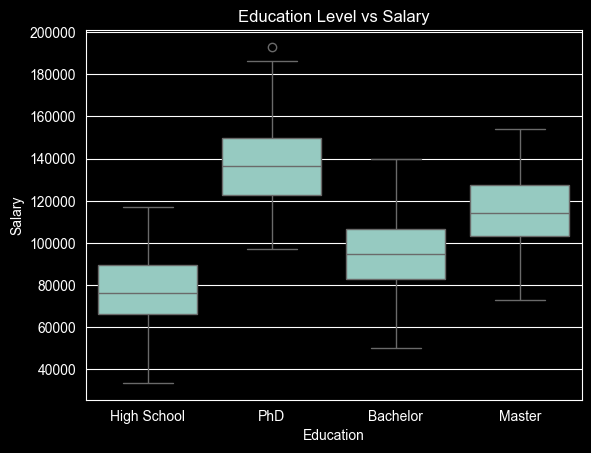

In [26]:
sns.boxplot(x="Education", y="Salary", data=df)
plt.title("Education Level vs Salary")
plt.show()

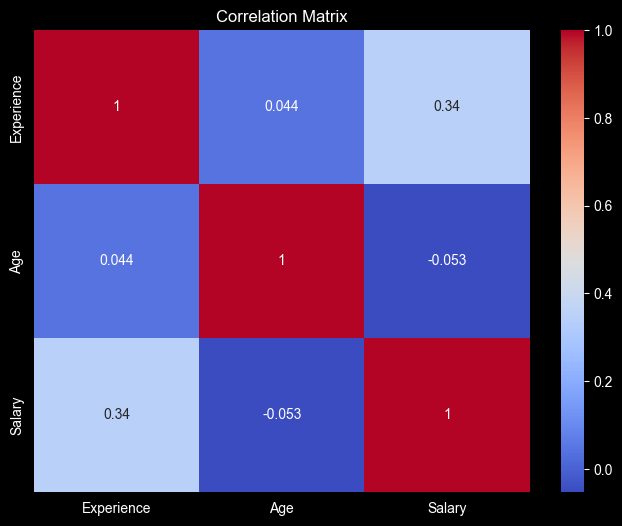

In [27]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

In [31]:
df = pd.get_dummies(df, drop_first=True)

In [32]:
X = df.drop("Salary", axis=1)
y = df["Salary"]

In [33]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [34]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [17]:
df = pd.get_dummies(df, drop_first=True)

In [36]:
X_encoded = pd.get_dummies(X, drop_first=True)

# convert everything to float
X_encoded = X_encoded.astype(float)

vif = pd.DataFrame()
vif["Feature"] = X_encoded.columns
vif["VIF"] = [variance_inflation_factor(X_encoded.values, i)
              for i in range(X_encoded.shape[1])]

vif

,Feature,VIF
0,Experience,3.800507
1,Age,6.263839
2,Education_High School,1.868674
3,Education_Master,1.797716
4,Education_PhD,1.817410
5,Location_Suburban,1.970814
6,Location_Urban,1.856867
7,Job_Title_Director,1.901061
8,Job_Title_Engineer,1.766581
9,Job_Title_Manager,1.780277


In [37]:
model = LinearRegression()

model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [38]:
y_pred = model.predict(X_test)

In [39]:
mae = mean_absolute_error(y_test, y_pred)

In [40]:
mse = mean_squared_error(y_test, y_pred)

In [41]:
rmse = np.sqrt(mse)

In [42]:
r2 = r2_score(y_test, y_pred)

In [43]:
print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 8157.898478643175
MSE: 105996277.6609688
RMSE: 10295.449366636154
R2 Score: 0.8701863681609701


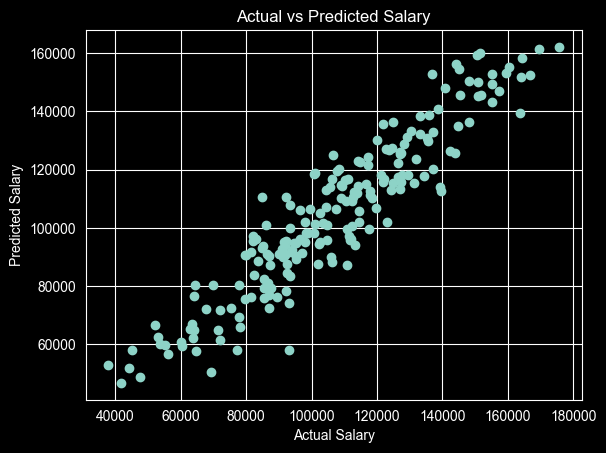

In [44]:
plt.scatter(y_test, y_pred)

plt.xlabel("Actual Salary")
plt.ylabel("Predicted Salary")
plt.title("Actual vs Predicted Salary")

plt.show()

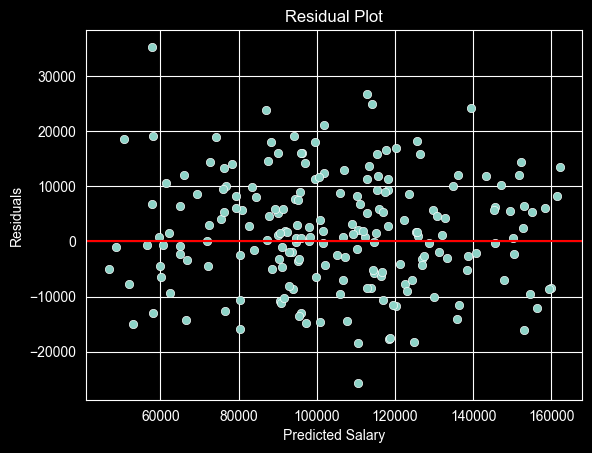

In [45]:
residuals = y_test - y_pred

sns.scatterplot(x=y_pred, y=residuals)

plt.axhline(0, color='red')

plt.xlabel("Predicted Salary")
plt.ylabel("Residuals")

plt.title("Residual Plot")

plt.show()